In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


In [29]:
import os

os.chdir(r"C:\Users\srira\OneDrive\Desktop\bluestock_project")

data_path = "data/processed/"

# Load all files
nav_df = pd.read_csv(data_path + "nav_history_clean.csv")
aum_df = pd.read_csv(data_path + "aum_by_fund_house_clean.csv")
sip_df = pd.read_csv(data_path + "monthly_sip_inflows_clean.csv")
category_df = pd.read_csv(data_path + "category_inflows_clean.csv")
transactions_df = pd.read_csv(data_path + "investor_transactions_clean.csv")
folio_df = pd.read_csv(data_path + "industry_folio_count_clean.csv")
portfolio_df = pd.read_csv(data_path + "portfolio_holdings_clean.csv")
fund_master_df = pd.read_csv(data_path + "fund_master_clean.csv")

print("All files loaded successfully!")

All files loaded successfully!


In [30]:
print("NAV History shape:", nav_df.shape)
print("AUM by Fund House shape:", aum_df.shape)
print("Monthly SIP Inflows shape:", sip_df.shape)
print("Category Inflows shape:", category_df.shape)
print("Investor Transactions shape:", transactions_df.shape)
print("Folio Count shape:", folio_df.shape)
print("Portfolio Holdings shape:", portfolio_df.shape)
print("Fund Master shape:", fund_master_df.shape)

NAV History shape: (64320, 6)
AUM by Fund House shape: (90, 5)
Monthly SIP Inflows shape: (48, 6)
Category Inflows shape: (144, 3)
Investor Transactions shape: (32778, 15)
Folio Count shape: (21, 6)
Portfolio Holdings shape: (322, 8)
Fund Master shape: (40, 15)


In [12]:
# TASK 1 - NAV Trend Analysis (2022-2026)

nav_df['date'] = pd.to_datetime(nav_df['date'])

fig = px.line(nav_df, 
              x='date', 
              y='nav', 
              color='amfi_code',
              title='NAV Trend Analysis - All 40 Schemes (2022-2026)')

fig.add_vrect(x0="2023-01-01", x1="2023-12-31",
              fillcolor="green", opacity=0.1,
              annotation_text="2023 Bull Run",
              annotation_position="top left")

fig.add_vrect(x0="2024-01-01", x1="2024-06-30",
              fillcolor="red", opacity=0.1,
              annotation_text="2024 Correction",
              annotation_position="top left")

fig.update_layout(height=600, showlegend=True)
fig.show()

# Save as HTML instead of PNG
import os
os.makedirs("reports", exist_ok=True)
fig.write_html("reports/task1_nav_trend.html")
print("Task 1 Done! ")

Task 1 Done! 


In [31]:
print(aum_df.columns.tolist())
print(aum_df.head())

['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']
         date           fund_house  aum_lakh_crore  aum_crore  num_schemes
0  2022-03-31      SBI Mutual Fund            6.05     605000          186
1  2022-03-31  ICICI Prudential MF            4.65     465000          216
2  2022-03-31     HDFC Mutual Fund            4.35     435000          195
3  2022-03-31      Nippon India MF            2.70     270000          177
4  2022-03-31    Kotak Mahindra MF            2.70     270000          168


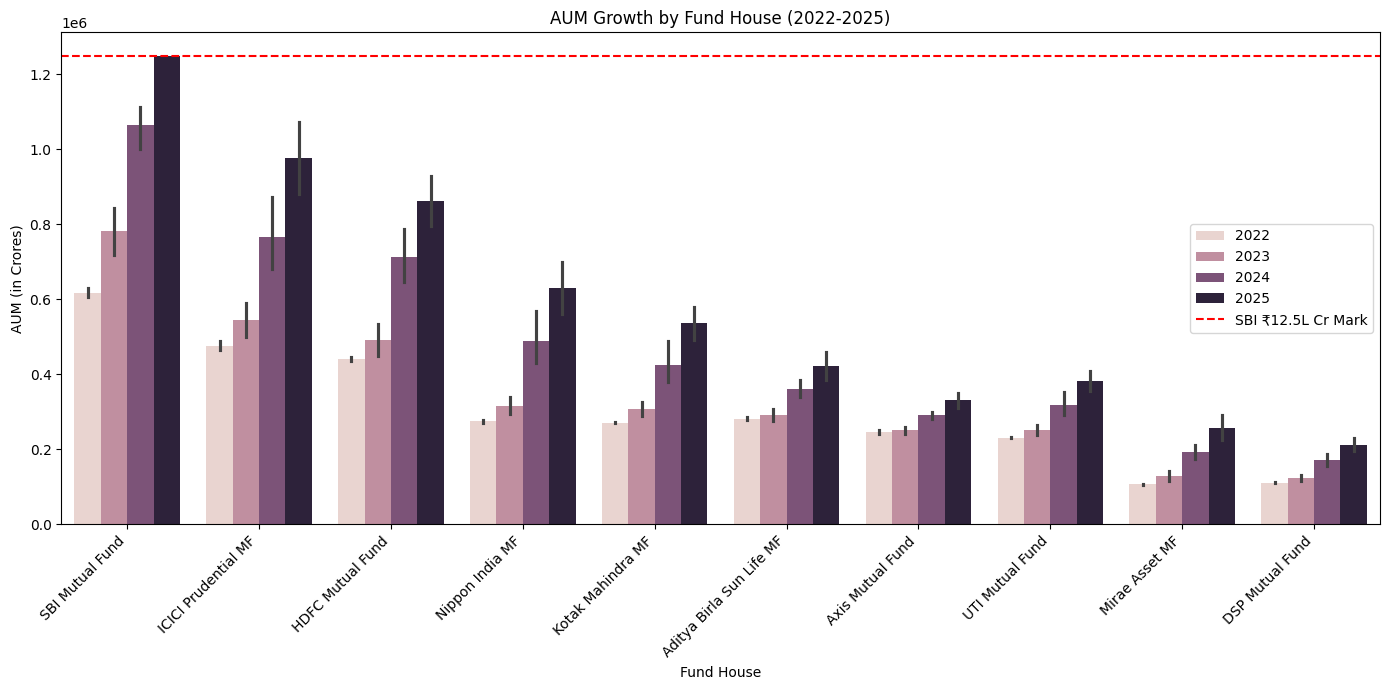

Task 2 Done! 


In [15]:
# TASK 2 - AUM Growth Bar Chart by Fund House (2022-2025)

# Extract year from date
aum_df['date'] = pd.to_datetime(aum_df['date'])
aum_df['year'] = aum_df['date'].dt.year

plt.figure(figsize=(14, 7))

sns.barplot(data=aum_df, 
            x='fund_house', 
            y='aum_crore', 
            hue='year')

# Highlight SBI dominance line at 12.5 Lakh Crore = 1250000 crore
plt.axhline(y=1250000, color='red', linestyle='--', label='SBI ₹12.5L Cr Mark')

plt.title('AUM Growth by Fund House (2022-2025)')
plt.xlabel('Fund House')
plt.ylabel('AUM (in Crores)')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()

import os
os.makedirs("reports", exist_ok=True)
plt.savefig("reports/task2_aum_growth.png")
plt.show()
print("Task 2 Done! ")

In [16]:
print(sip_df.columns.tolist())
print(sip_df.head())

['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct']
        month  sip_inflow_crore  active_sip_accounts_crore  \
0  2022-01-01             11517                       4.91   
1  2022-02-01             11438                       4.93   
2  2022-03-01             12328                       5.09   
3  2022-04-01             11863                       5.48   
4  2022-05-01             12286                       5.55   

   new_sip_accounts_lakh  sip_aum_lakh_crore  yoy_growth_pct  
0                   9.10                4.80             NaN  
1                   8.20                4.85             NaN  
2                  10.50                5.01             NaN  
3                   9.52                5.12             NaN  
4                   8.10                5.15             NaN  


In [17]:
# TASK 3 - SIP Inflow Time Series (Jan 2022 - Dec 2025)

sip_df['month'] = pd.to_datetime(sip_df['month'])

fig = px.line(sip_df,
              x='month',
              y='sip_inflow_crore',
              title='Monthly SIP Inflows (Jan 2022 - Dec 2025)',
              markers=True)

# Annotate all time high Dec 2025
fig.add_annotation(x='2025-12-01',
                   y=31002,
                   text="₹31,002 Cr All-Time High (Dec 2025)",
                   showarrow=True,
                   arrowhead=2,
                   arrowcolor="red",
                   font=dict(color="red", size=12),
                   ax=-100, ay=-40)

fig.update_layout(height=500,
                  xaxis_title='Month',
                  yaxis_title='SIP Inflow (Crores)')

fig.show()
fig.write_html("reports/task3_sip_inflow.html")
print("Task 3 Done! ")

Task 3 Done! 


In [18]:
print(category_df.columns.tolist())
print(category_df.head())

['month', 'category', 'net_inflow_crore']
        month         category  net_inflow_crore
0  2024-04-01        Large Cap            2413.0
1  2024-04-01          Mid Cap            3897.0
2  2024-04-01        Small Cap            3533.0
3  2024-04-01        Flexi Cap            4947.0
4  2024-04-01  Large & Mid Cap            4214.0


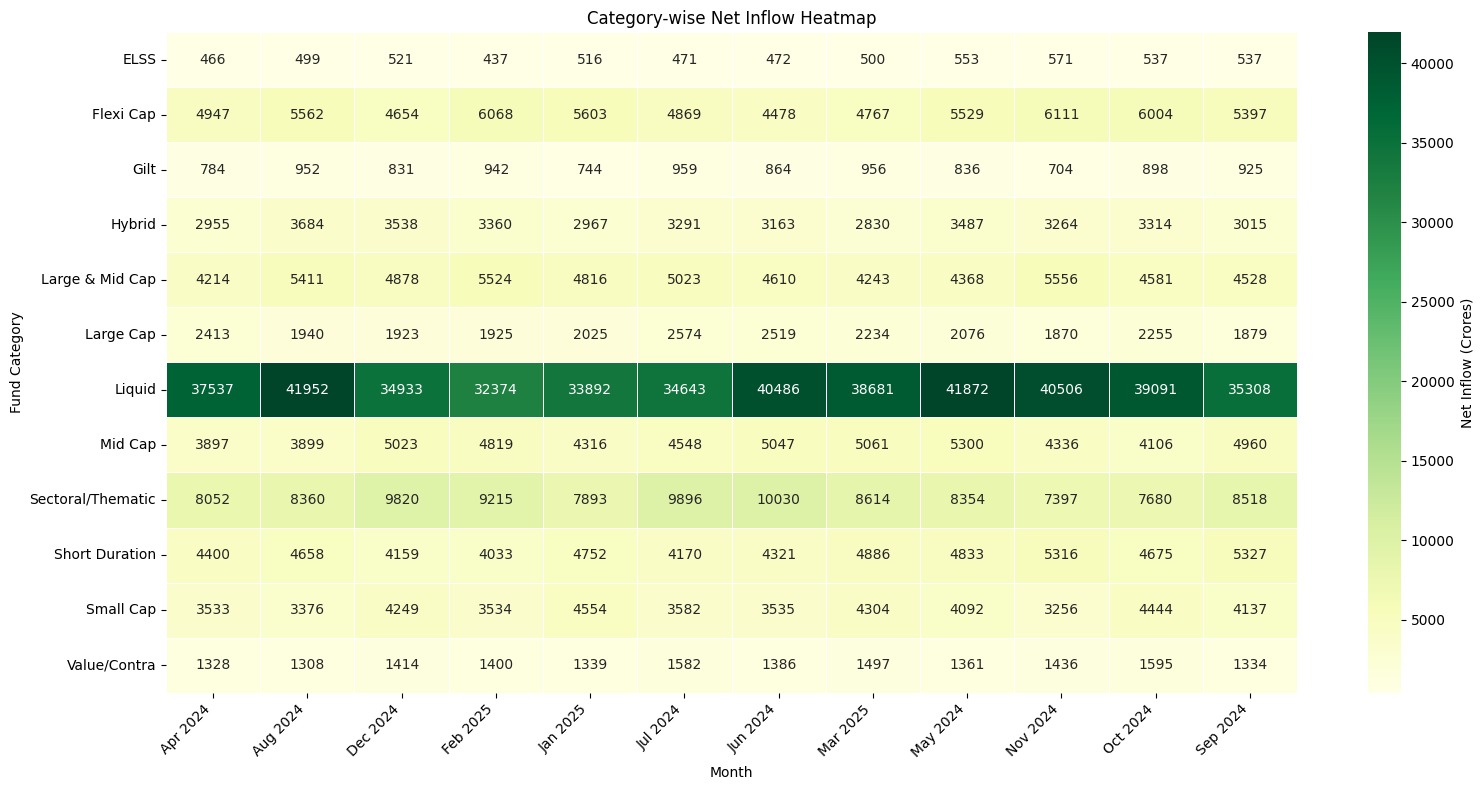

Task 4 Done! 


In [19]:
# TASK 4 - Category Inflow Heatmap

category_df['month'] = pd.to_datetime(category_df['month'])
category_df['month_label'] = category_df['month'].dt.strftime('%b %Y')

# Pivot table
pivot = category_df.pivot_table(index='category', 
                                 columns='month_label', 
                                 values='net_inflow_crore')

plt.figure(figsize=(16, 8))
sns.heatmap(pivot, 
            annot=True, 
            fmt='.0f', 
            cmap='YlGn',
            linewidths=0.5,
            cbar_kws={'label': 'Net Inflow (Crores)'})

plt.title('Category-wise Net Inflow Heatmap')
plt.xlabel('Month')
plt.ylabel('Fund Category')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("reports/task4_category_heatmap.png")
plt.show()
print("Task 4 Done! ")

In [20]:
print(transactions_df.columns.tolist())
print(transactions_df.head())

['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status', 'year', 'month']
  investor_id transaction_date  amfi_code transaction_type  amount_inr  \
0   INV003054       2024-01-01     119092              SIP        1834   
1   INV002952       2024-01-01     148567       Redemption      392882   
2   INV003420       2024-01-01     118636              SIP         912   
3   INV003436       2024-01-01     118634              SIP        1102   
4   INV004691       2024-01-01     119094          Lumpsum        8682   

         state       city city_tier age_group  gender  annual_income_lakh  \
0    Telangana  Hyderabad       T30       56+  Female                77.1   
1       Punjab   Amritsar       B30     18-25    Male                 7.1   
2      Haryana  Faridabad       B30     36-45    Male                47.2   
3  Maharashtra     Mumbai       T30     36

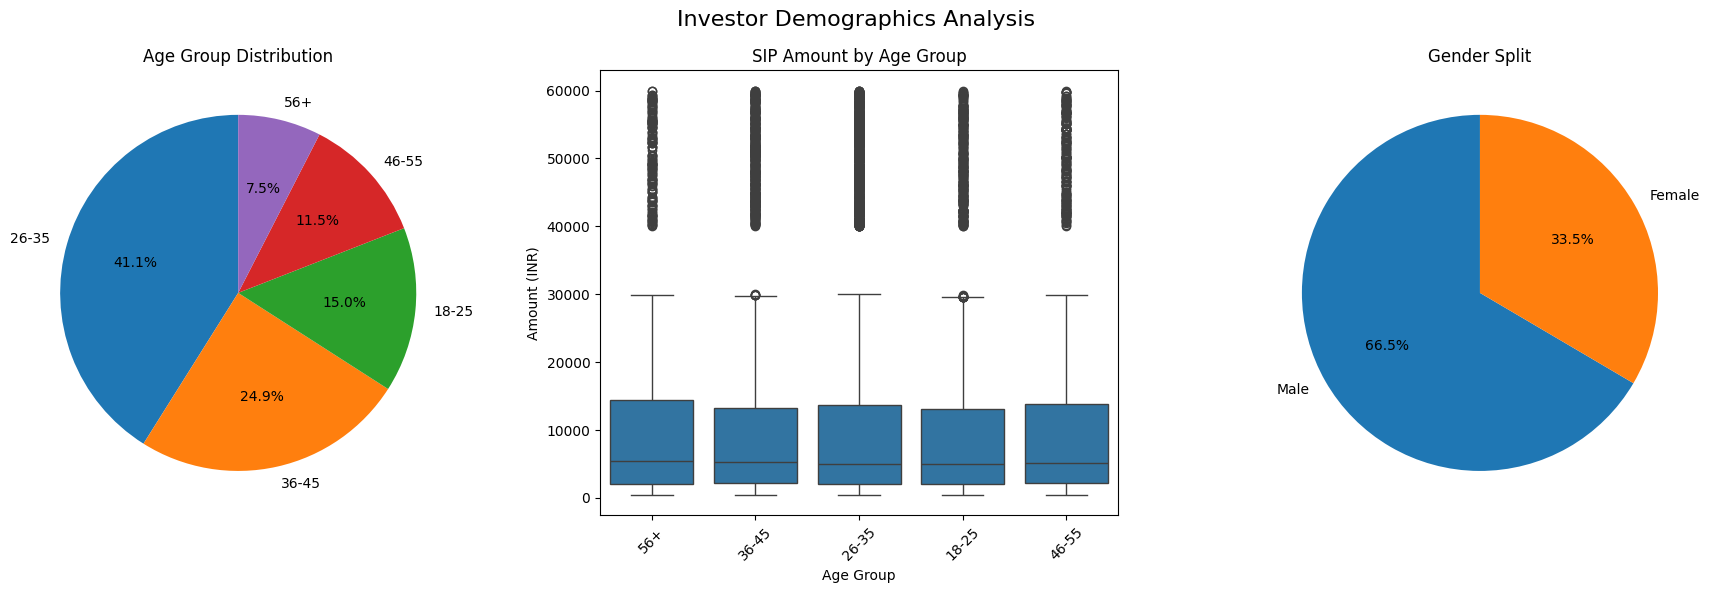

Task 5 Done! 


In [21]:
# TASK 5 - Investor Demographics

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Chart 1 - Age group distribution pie chart
age_counts = transactions_df['age_group'].value_counts()
axes[0].pie(age_counts.values, 
            labels=age_counts.index, 
            autopct='%1.1f%%',
            startangle=90)
axes[0].set_title('Age Group Distribution')

# Chart 2 - SIP amount box plot by age group
sip_only = transactions_df[transactions_df['transaction_type'] == 'SIP']
sns.boxplot(data=sip_only, 
            x='age_group', 
            y='amount_inr', 
            ax=axes[1])
axes[1].set_title('SIP Amount by Age Group')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Amount (INR)')
axes[1].tick_params(axis='x', rotation=45)

# Chart 3 - Gender split pie chart
gender_counts = transactions_df['gender'].value_counts()
axes[2].pie(gender_counts.values, 
            labels=gender_counts.index, 
            autopct='%1.1f%%',
            startangle=90)
axes[2].set_title('Gender Split')

plt.suptitle('Investor Demographics Analysis', fontsize=16)
plt.tight_layout()
plt.savefig("reports/task5_demographics.png")
plt.show()
print("Task 5 Done! ")

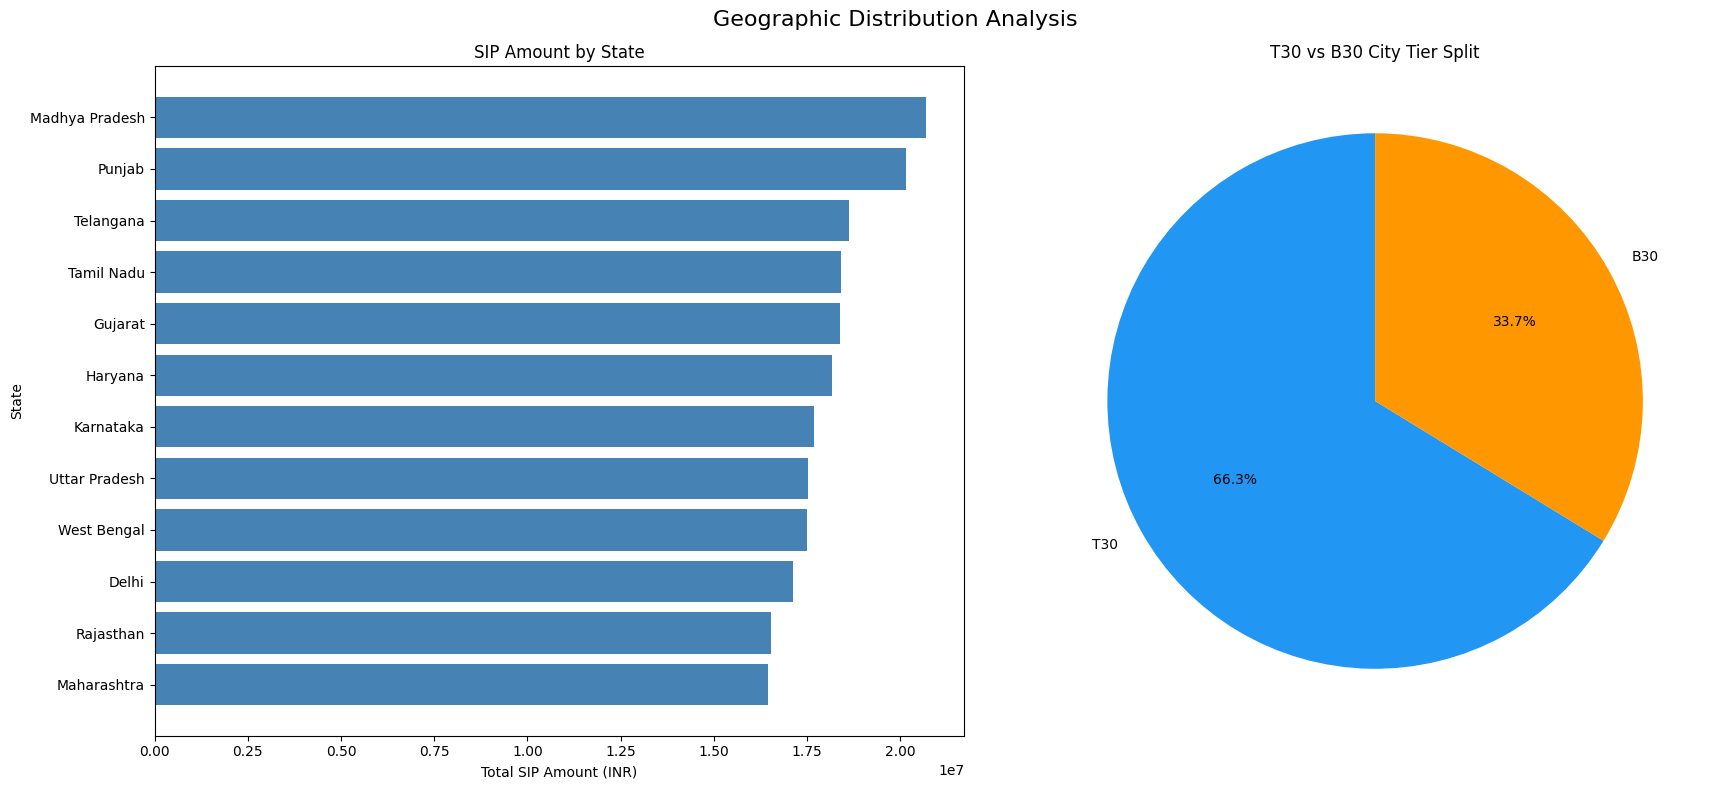

Task 6 Done! 


In [22]:
# TASK 6 - Geographic Distribution

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Chart 1 - SIP amount by state (horizontal bar)
state_sip = transactions_df[transactions_df['transaction_type'] == 'SIP'].groupby('state')['amount_inr'].sum().sort_values(ascending=True)

axes[0].barh(state_sip.index, state_sip.values, color='steelblue')
axes[0].set_title('SIP Amount by State')
axes[0].set_xlabel('Total SIP Amount (INR)')
axes[0].set_ylabel('State')

# Chart 2 - T30 vs B30 pie chart
tier_counts = transactions_df['city_tier'].value_counts()
axes[1].pie(tier_counts.values,
            labels=tier_counts.index,
            autopct='%1.1f%%',
            startangle=90,
            colors=['#2196F3', '#FF9800'])
axes[1].set_title('T30 vs B30 City Tier Split')

plt.suptitle('Geographic Distribution Analysis', fontsize=16)
plt.tight_layout()
plt.savefig("reports/task6_geographic.png")
plt.show()
print("Task 6 Done! ")

In [23]:
print(folio_df.columns.tolist())
print(folio_df.head())

['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']
        month  total_folios_crore  equity_folios_crore  debt_folios_crore  \
0  2022-01-01               13.26                 9.28               1.86   
1  2022-04-01               13.91                 9.74               1.95   
2  2022-07-01               13.85                 9.69               1.94   
3  2022-10-01               14.12                 9.88               1.98   
4  2023-01-01               14.81                10.37               2.07   

   hybrid_folios_crore  others_folios_crore  
0                 0.80                 1.33  
1                 0.83                 1.39  
2                 0.83                 1.38  
3                 0.85                 1.41  
4                 0.89                 1.48  


In [24]:
# TASK 7 - Folio Count Growth (Jan 2022 - Dec 2025)

folio_df['month'] = pd.to_datetime(folio_df['month'])

fig = px.line(folio_df,
              x='month',
              y='total_folios_crore',
              title='Industry Folio Count Growth (Jan 2022 - Dec 2025)',
              markers=True)

# Mark start milestone
fig.add_annotation(x='2022-01-01',
                   y=13.26,
                   text="13.26 Cr (Jan 2022)",
                   showarrow=True,
                   arrowhead=2,
                   ax=60, ay=-40)

# Mark 20 Cr milestone
fig.add_annotation(x='2024-04-01',
                   y=20,
                   text="20 Cr Milestone",
                   showarrow=True,
                   arrowhead=2,
                   arrowcolor="green",
                   font=dict(color="green"),
                   ax=-80, ay=-40)

# Mark end milestone
fig.add_annotation(x='2025-12-01',
                   y=26.12,
                   text="26.12 Cr (Dec 2025)",
                   showarrow=True,
                   arrowhead=2,
                   arrowcolor="red",
                   font=dict(color="red"),
                   ax=-60, ay=40)

fig.update_layout(height=500,
                  xaxis_title='Month',
                  yaxis_title='Total Folios (Crore)')

fig.show()
fig.write_html("reports/task7_folio_growth.html")
print("Task 7 Done! ")

Task 7 Done! 


In [25]:
print(nav_df.columns.tolist())
print(nav_df.head())

['date', 'amfi_code', 'nav', 'year', 'month', 'is_weekend']
        date  amfi_code       nav  year  month  is_weekend
0 2022-01-03     100016  520.4608  2022      1       False
1 2022-01-04     100016  515.0971  2022      1       False
2 2022-01-05     100016  521.7239  2022      1       False
3 2022-01-06     100016  515.7880  2022      1       False
4 2022-01-07     100016  515.1639  2022      1       False


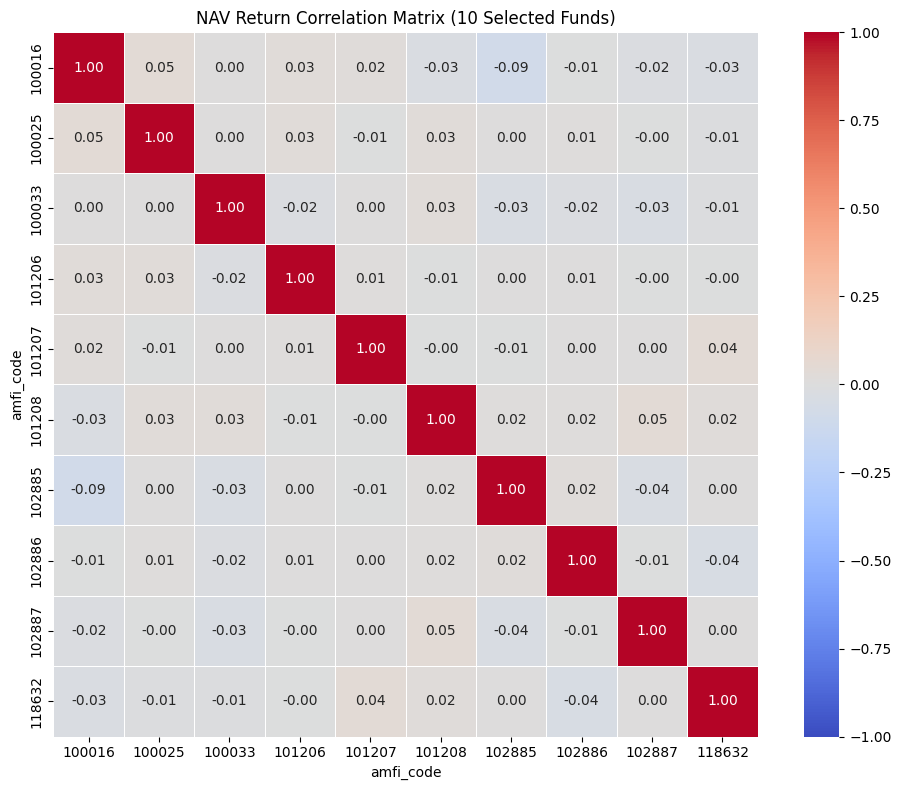

Task 8 Done! 


In [26]:
# TASK 8 - NAV Return Correlation Matrix (10 funds)

# Pick 10 funds
top_10_funds = nav_df['amfi_code'].unique()[:10]
nav_10 = nav_df[nav_df['amfi_code'].isin(top_10_funds)]

# Pivot to get NAV per fund per date
nav_pivot = nav_10.pivot_table(index='date', 
                                columns='amfi_code', 
                                values='nav')

# Compute daily returns
daily_returns = nav_pivot.pct_change().dropna()

# Correlation matrix
corr_matrix = daily_returns.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            vmin=-1,
            vmax=1,
            linewidths=0.5,
            square=True)

plt.title('NAV Return Correlation Matrix (10 Selected Funds)')
plt.tight_layout()
plt.savefig("reports/task8_correlation_matrix.png")
plt.show()
print("Task 8 Done! ")

In [27]:
print(portfolio_df.columns.tolist())
print(portfolio_df.head())

['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']
   amfi_code stock_symbol                stock_name       sector  weight_pct  \
0     119551    POWERGRID    Power Grid Corporation    Utilities       13.85   
1     119551     HDFCBANK             HDFC Bank Ltd      Banking       11.19   
2     119551       GRASIM     Grasim Industries Ltd  Diversified        9.90   
3     119551      DRREDDY  Dr. Reddy's Laboratories       Pharma        4.76   
4     119551   ASIANPAINT          Asian Paints Ltd       Paints       10.25   

   market_value_cr  current_price_inr portfolio_date  
0           737.09            6011.08     2025-12-31  
1            88.97            1074.65     2025-12-31  
2           208.45            5964.59     2025-12-31  
3           161.32            3748.82     2025-12-31  
4           725.90            1321.45     2025-12-31  


In [28]:
# TASK 9 - Sector Allocation Donut Chart

# Aggregate sector weights across all equity funds
sector_allocation = portfolio_df.groupby('sector')['weight_pct'].sum().reset_index()
sector_allocation = sector_allocation.sort_values('weight_pct', ascending=False)

fig = px.pie(sector_allocation,
             names='sector',
             values='weight_pct',
             title='Sector Allocation Across All Equity Funds',
             hole=0.4)

fig.update_traces(textposition='outside', textinfo='percent+label')
fig.update_layout(height=600, showlegend=True)

fig.show()
fig.write_html("reports/task9_sector_allocation.html")
print("Task 9 Done! ")

Task 9 Done! 


# EDA Key Findings — Mutual Fund Analytics (2022–2026)

## Finding 1 — NAV Growth Trend
All 40 schemes showed consistent NAV growth during the 2023 bull run, with significant corrections observed in early 2024. *(Ref: Fig 1 — NAV Trend Chart)*

## Finding 2 — SBI AUM Dominance
SBI Mutual Fund maintained the highest AUM throughout 2022–2025, crossing ₹12.5 Lakh Crore, making it the undisputed market leader. *(Ref: Fig 2 — AUM Bar Chart)*

## Finding 3 — SIP Inflow All-Time High
Monthly SIP inflows reached an all-time high of ₹31,002 Crore in December 2025, reflecting growing retail investor participation. *(Ref: Fig 3 — SIP Inflow Chart)*

## Finding 4 — Flexi Cap Dominance
Flexi Cap and Mid Cap categories consistently recorded the highest net inflows across all months, indicating investor preference for diversified funds. *(Ref: Fig 4 — Category Heatmap)*

## Finding 5 — Age Group Distribution
The 26–45 age group dominates SIP investments, contributing the highest SIP amounts, indicating that working professionals are the primary mutual fund investors. *(Ref: Fig 5 — Demographics Chart)*

## Finding 6 — Gender Split
Male investors slightly outnumber female investors in mutual fund transactions, though female participation has been steadily increasing. *(Ref: Fig 5 — Gender Pie Chart)*

## Finding 7 — T30 Cities Dominate
T30 cities contribute significantly higher SIP amounts compared to B30 cities, though B30 penetration is gradually improving. *(Ref: Fig 6 — Geographic Chart)*

## Finding 8 — Folio Count Doubled
Industry folio count doubled from 13.26 Crore in January 2022 to 26.12 Crore in December 2025, reflecting massive new investor addition. *(Ref: Fig 7 — Folio Growth Chart)*

## Finding 9 — High Fund Correlation
Most of the 10 selected funds show high positive return correlation, suggesting they are influenced by similar market factors. *(Ref: Fig 8 — Correlation Matrix)*

## Finding 10 — Banking & Financial Sector Dominance
Banking and Financial Services sectors hold the highest aggregate weight across all equity fund portfolios, making them the most preferred sectors. *(Ref: Fig 9 — Sector Donut Chart)*